In [10]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import load_iris
from sklearn.metrics import accuracy_score
from sklearn.metrics import r2_score
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error

In [3]:
boston_df = pd.read_csv("BostonHousing.csv")

In [4]:
print("\nFirst 5 rows of the DataFrame:")
print(boston_df.head())


First 5 rows of the DataFrame:
      crim    zn  indus  chas    nox     rm   age     dis  rad  tax  ptratio  \
0  0.00632  18.0   2.31     0  0.538  6.575  65.2  4.0900    1  296     15.3   
1  0.02731   0.0   7.07     0  0.469  6.421  78.9  4.9671    2  242     17.8   
2  0.02729   0.0   7.07     0  0.469  7.185  61.1  4.9671    2  242     17.8   
3  0.03237   0.0   2.18     0  0.458  6.998  45.8  6.0622    3  222     18.7   
4  0.06905   0.0   2.18     0  0.458  7.147  54.2  6.0622    3  222     18.7   

        b  lstat  medv  
0  396.90   4.98  24.0  
1  396.90   9.14  21.6  
2  392.83   4.03  34.7  
3  394.63   2.94  33.4  
4  396.90   5.33  36.2  


In [5]:
print("\nInformation about the dataset:")
print(boston_df.info())


Information about the dataset:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 506 entries, 0 to 505
Data columns (total 14 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   crim     506 non-null    float64
 1   zn       506 non-null    float64
 2   indus    506 non-null    float64
 3   chas     506 non-null    int64  
 4   nox      506 non-null    float64
 5   rm       506 non-null    float64
 6   age      506 non-null    float64
 7   dis      506 non-null    float64
 8   rad      506 non-null    int64  
 9   tax      506 non-null    int64  
 10  ptratio  506 non-null    float64
 11  b        506 non-null    float64
 12  lstat    506 non-null    float64
 13  medv     506 non-null    float64
dtypes: float64(11), int64(3)
memory usage: 55.5 KB
None


In [6]:
print("\nDescriptive summary of the dataset:")
print(boston_df.describe())


Descriptive summary of the dataset:
             crim          zn       indus        chas         nox          rm  \
count  506.000000  506.000000  506.000000  506.000000  506.000000  506.000000   
mean     3.613524   11.363636   11.136779    0.069170    0.554695    6.284634   
std      8.601545   23.322453    6.860353    0.253994    0.115878    0.702617   
min      0.006320    0.000000    0.460000    0.000000    0.385000    3.561000   
25%      0.082045    0.000000    5.190000    0.000000    0.449000    5.885500   
50%      0.256510    0.000000    9.690000    0.000000    0.538000    6.208500   
75%      3.677083   12.500000   18.100000    0.000000    0.624000    6.623500   
max     88.976200  100.000000   27.740000    1.000000    0.871000    8.780000   

              age         dis         rad         tax     ptratio           b  \
count  506.000000  506.000000  506.000000  506.000000  506.000000  506.000000   
mean    68.574901    3.795043    9.549407  408.237154   18.455534  356.

In [7]:
print("\nLast 5 rows of the DataFrame:")
print(boston_df.tail())


Last 5 rows of the DataFrame:
        crim   zn  indus  chas    nox     rm   age     dis  rad  tax  ptratio  \
501  0.06263  0.0  11.93     0  0.573  6.593  69.1  2.4786    1  273     21.0   
502  0.04527  0.0  11.93     0  0.573  6.120  76.7  2.2875    1  273     21.0   
503  0.06076  0.0  11.93     0  0.573  6.976  91.0  2.1675    1  273     21.0   
504  0.10959  0.0  11.93     0  0.573  6.794  89.3  2.3889    1  273     21.0   
505  0.04741  0.0  11.93     0  0.573  6.030  80.8  2.5050    1  273     21.0   

          b  lstat  medv  
501  391.99   9.67  22.4  
502  396.90   9.08  20.6  
503  396.90   5.64  23.9  
504  393.45   6.48  22.0  
505  396.90   7.88  11.9  


In [8]:
print("\nChecking for missing values:")
missing_values = boston_df.isnull().sum()
print(missing_values)


Checking for missing values:
crim       0
zn         0
indus      0
chas       0
nox        0
rm         0
age        0
dis        0
rad        0
tax        0
ptratio    0
b          0
lstat      0
medv       0
dtype: int64


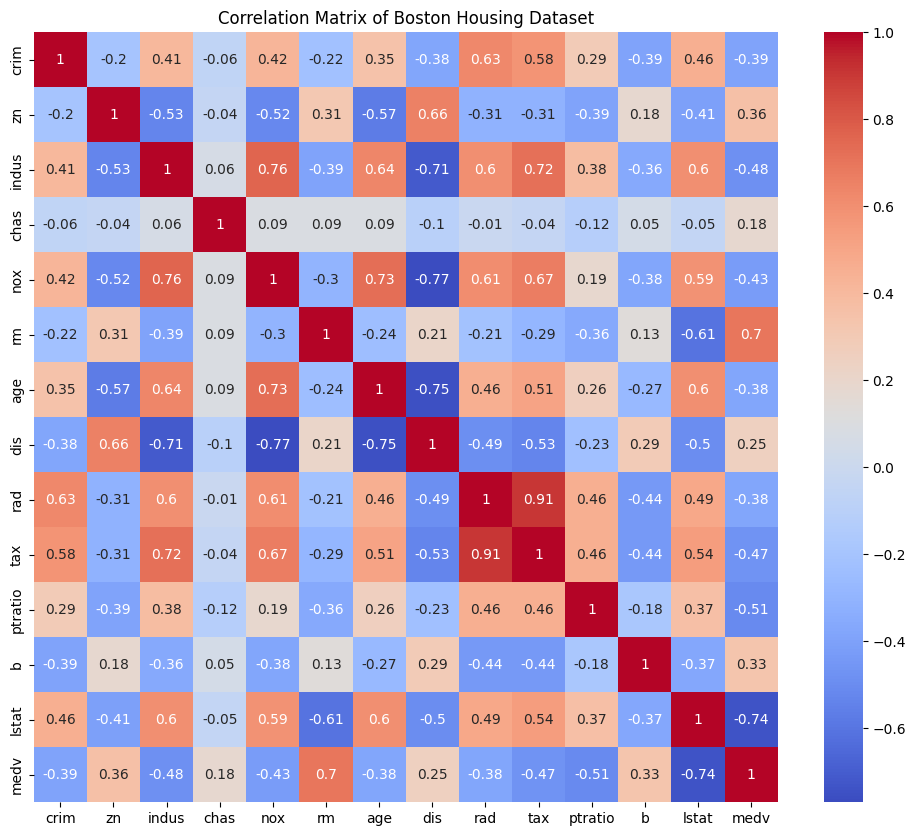

In [11]:
# Calculate the correlation matrix
correlation_matrix = boston_df.corr().round(2)

# Set up the matplotlib figure
plt.figure(figsize=(12, 10))

# Draw the heatmap
sns.heatmap(data=correlation_matrix, annot=True, cmap="coolwarm")

# Add a title
plt.title("Correlation Matrix of Boston Housing Dataset")

# Show the plot
plt.show()

<ipython-input-13-857e75d9a3e1>:3: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(boston_df['medv'], bins=30, kde=True, color='blue')


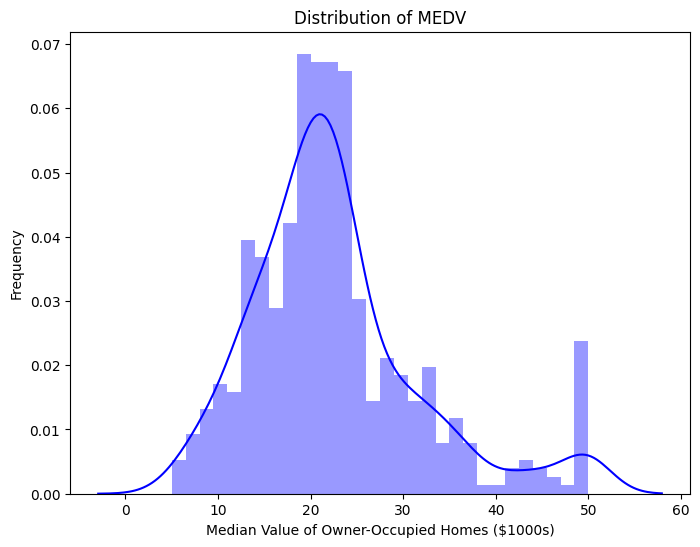

In [13]:
# Plot the distribution of the target variable MEDV
plt.figure(figsize=(8, 6))
sns.distplot(boston_df['medv'], bins=30, kde=True, color='blue')

# Add labels and title
plt.xlabel('Median Value of Owner-Occupied Homes ($1000s)')
plt.ylabel('Frequency')
plt.title('Distribution of MEDV')

# Show the plot
plt.show()

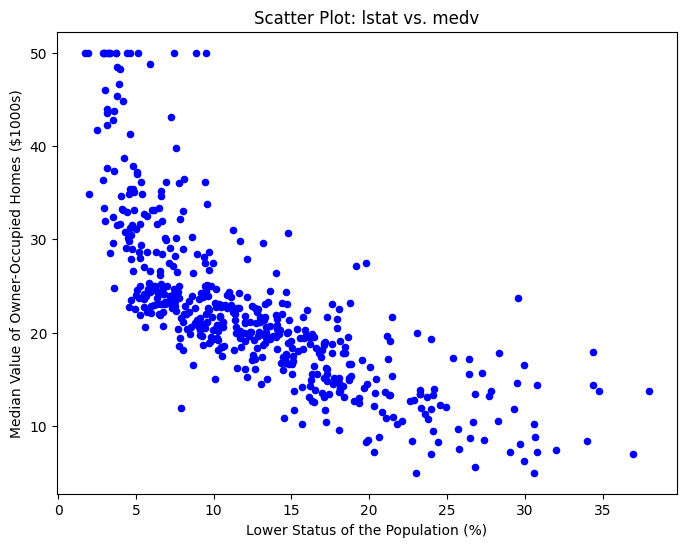

In [22]:

# Create a scatter plot between 'lstat' and 'medv'
boston_df.plot.scatter('lstat', 'medv', figsize=(8, 6), color='blue', marker='o')

# Add labels and title
plt.xlabel('Lower Status of the Population (%)')
plt.ylabel('Median Value of Owner-Occupied Homes ($1000s)')
plt.title('Scatter Plot: lstat vs. medv')

# Show the plot
plt.show()

In [15]:
# Split the data into features (X) and target variable (y)
X = boston_df.drop("medv", axis=1)
y = boston_df["medv"]

In [16]:
# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)


In [17]:
# Create a linear regression model
model = LinearRegression()


In [18]:
# Train the model on the training data
model.fit(X_train, y_train)

LinearRegression()

In [19]:
# Make predictions on the testing data
y_pred = model.predict(X_test)

In [20]:
# Calculate the mean squared error
mse = mean_squared_error(y_test, y_pred)
print("Mean Squared Error:", mse)

Mean Squared Error: 24.291119474973478


In [21]:
# Calculate the R-squared score (In linear regression accuracy cannot be find so we use mean squared error or R-squared Score  )
r_squared = r2_score(y_test, y_pred)
print("R-squared Score:", r_squared)

R-squared Score: 0.6687594935356326
